In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [7]:
df = pd.read_csv('Diagnostic Breast Cancer Dataset.csv')

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nMissing Values Check:")
print(df.isnull().sum().sum(), "missing values found")

print(df['Diagnosis'].value_counts())
print(f"\nBenign: {df['Diagnosis'].value_counts()['Benign']} ({df['Diagnosis'].value_counts(normalize=True)['Benign']*100:.1f}%)")
print(f"Malignant: {df['Diagnosis'].value_counts()['Malignant']} ({df['Diagnosis'].value_counts(normalize=True)['Malignant']*100:.1f}%)")


Dataset Shape: 569 rows × 32 columns

First 5 rows of the dataset:
         ID  Mean Radius  Mean Texture  Mean Perimeter  Mean Area  \
0    842302        17.99         10.38          122.80     1001.0   
1    842517        20.57         17.77          132.90     1326.0   
2  84300903        19.69         21.25          130.00     1203.0   
3  84348301        11.42         20.38           77.58      386.1   
4  84358402        20.29         14.34          135.10     1297.0   

   Mean Smoothness  Mean Compactness  Mean Concavity  Mean Concave Points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   Mean Symmetry  ...  Worst Texture  Worst Perimeter 

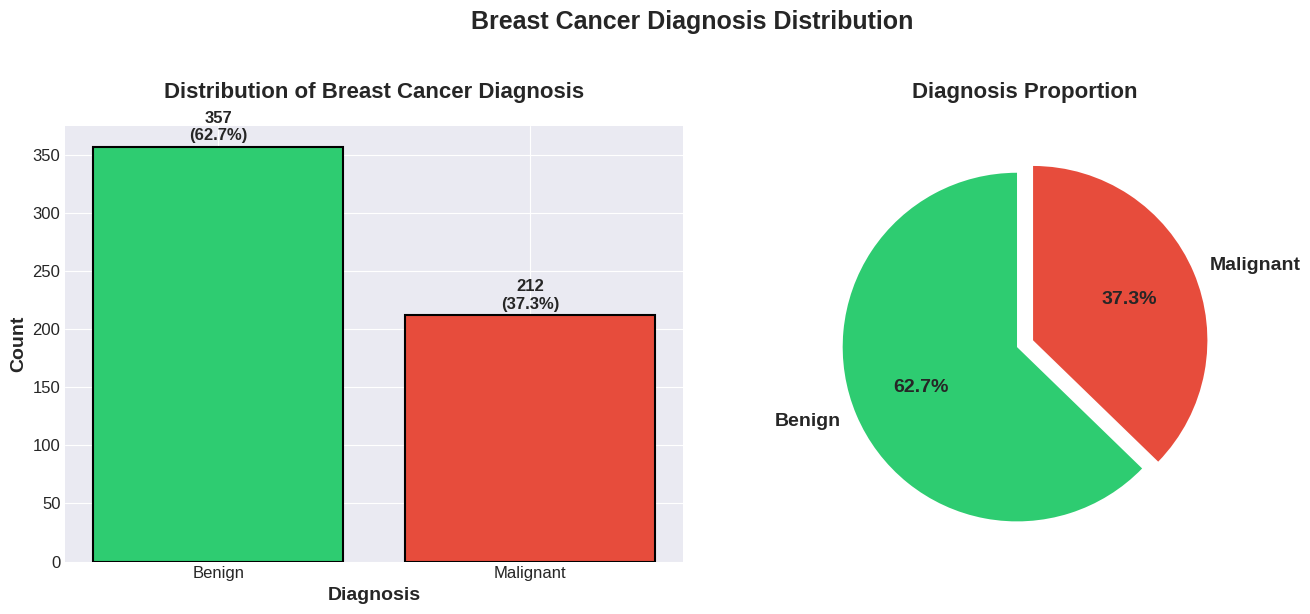

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
counts = df['Diagnosis'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Diagnosis', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count', fontsize=14, fontweight='bold')
ax1.set_title('Distribution of Breast Cancer Diagnosis', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(['Benign', 'Malignant'])
ax1.set_xticklabels(['Benign', 'Malignant'], fontsize=12)

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2 = axes[1]
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax2.pie(counts.values, labels=['Benign', 'Malignant'], autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90, explode=(0.05, 0.05),
                                    textprops={'fontsize': 14, 'fontweight': 'bold'})
ax2.set_title('Diagnosis Proportion', fontsize=16, fontweight='bold', pad=20)

plt.suptitle('Breast Cancer Diagnosis Distribution', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
id_column = df['ID']
print(f"ID Column Statistics:")
print(f"  • Number of unique IDs: {id_column.nunique()}")
print(f"  • Total patients: {len(id_column)}")
print(f"  • Duplicate IDs: {id_column.duplicated().sum()}")
print(f"  • ID range: {id_column.min()} to {id_column.max()}")
print(f"  • Data type: {id_column.dtype}")

id_diff = id_column.sort_values().diff().dropna()
print(f"\nID Pattern Analysis:")
print(f"  • Mean gap between IDs: {id_diff.mean():.1f}")
print(f"  • Median gap: {id_diff.median():.0f}")
print(f"  • Min gap: {id_diff.min():.0f}")
print(f"  • Max gap: {id_diff.max():.0f}")

from scipy import stats
benign_ids = df[df['Diagnosis'] == 'Benign']['ID']
malignant_ids = df[df['Diagnosis'] == 'Malignant']['ID']
t_stat, p_value = stats.ttest_ind(benign_ids, malignant_ids)
print(f"\nT-test for ID difference between Benign and Malignant:")
print(f"  • T-statistic: {t_stat:.4f}")
print(f"  • P-value: {p_value:.4f}")
print(f"  • Conclusion: {'Significant difference' if p_value < 0.05 else 'No significant difference'} in IDs between groups")

ID Column Statistics:
  • Number of unique IDs: 569
  • Total patients: 569
  • Duplicate IDs: 0
  • ID range: 8670 to 911320502
  • Data type: int64

ID Pattern Analysis:
  • Mean gap between IDs: 1604422.2
  • Median gap: 222
  • Min gap: 1
  • Max gap: 779021800

T-test for ID difference between Benign and Malignant:
  • T-statistic: -0.9477
  • P-value: 0.3437
  • Conclusion: No significant difference in IDs between groups


In [14]:
df_processed = df.copy()

le = LabelEncoder()
df_processed['diagnosis_encoded'] = le.fit_transform(df_processed['Diagnosis'])
#Benign -> 0, Malignant -> 1
print(f"Target Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")


feature_columns = [col for col in df_processed.columns if col not in ['ID', 'Diagnosis', 'diagnosis_encoded']]
X = df_processed[feature_columns]
y = df_processed['diagnosis_encoded']

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")
print(f"\nFeature Names (first 10): {feature_columns[:10]}")

print(f"\nInfinite values: {np.isinf(X).sum().sum()}")
print(f"Null values: {X.isnull().sum().sum()}")

print(X.describe().T[['mean', 'std', 'min', 'max']].head(10))

Target Encoding: {'Benign': np.int64(0), 'Malignant': np.int64(1)}

Feature Matrix Shape: (569, 30)
Target Vector Shape: (569,)

Feature Names (first 10): ['Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness', 'Mean Compactness', 'Mean Concavity', 'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension']

Infinite values: 0
Null values: 0
                              mean         std        min         max
Mean Radius              14.127292    3.524049    6.98100    28.11000
Mean Texture             19.289649    4.301036    9.71000    39.28000
Mean Perimeter           91.969033   24.298981   43.79000   188.50000
Mean Area               654.889104  351.914129  143.50000  2501.00000
Mean Smoothness           0.096360    0.014064    0.05263     0.16340
Mean Compactness          0.104341    0.052813    0.01938     0.34540
Mean Concavity            0.088799    0.079720    0.00000     0.42680
Mean Concave Points       0.048919    0.038803    0.00000     0.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  Benign: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Malignant: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"\nTest set class distribution:")
print(f"  Benign: {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Malignant: {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.1f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("\nFeature Scaling Complete (StandardScaler - mean=0, std=1)")
print(f"Training data scaled shape: {X_train_scaled.shape}")
print(f"Test data scaled shape: {X_test_scaled.shape}")

print(f"\nVerification - Mean of scaled training features: {X_train_scaled.mean(axis=0).mean():.10f}")
print(f"Verification - Std of scaled training features: {X_train_scaled.std(axis=0).mean():.2f}")

Training set size: 455 samples (80.0%)
Test set size: 114 samples (20.0%)

Training set class distribution:
  Benign: 285 (62.6%)
  Malignant: 170 (37.4%)

Test set class distribution:
  Benign: 72 (63.2%)
  Malignant: 42 (36.8%)

Feature Scaling Complete (StandardScaler - mean=0, std=1)
Training data scaled shape: (455, 30)
Test data scaled shape: (114, 30)

Verification - Mean of scaled training features: 0.0000000000
Verification - Std of scaled training features: 1.00


Accuracy: 0.9649

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



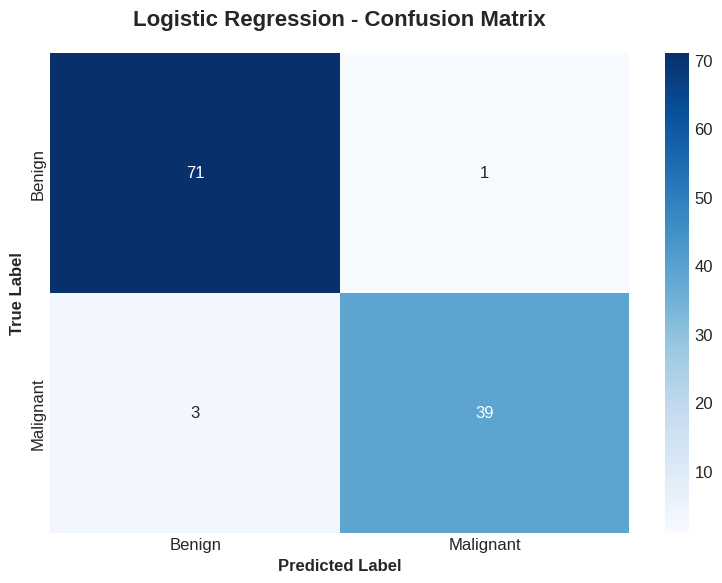


5-Fold Cross-Validation Scores: [0.96703297 0.98901099 0.95604396 0.97802198 0.96703297]
Mean CV Accuracy: 0.9714 (+/- 0.0224)


In [17]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)


accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy_log:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=['Benign', 'Malignant']))

cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Logistic Regression - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

cv_scores_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold Cross-Validation Scores: {cv_scores_log}")
print(f"Mean CV Accuracy: {cv_scores_log.mean():.4f} (+/- {cv_scores_log.std()*2:.4f})")

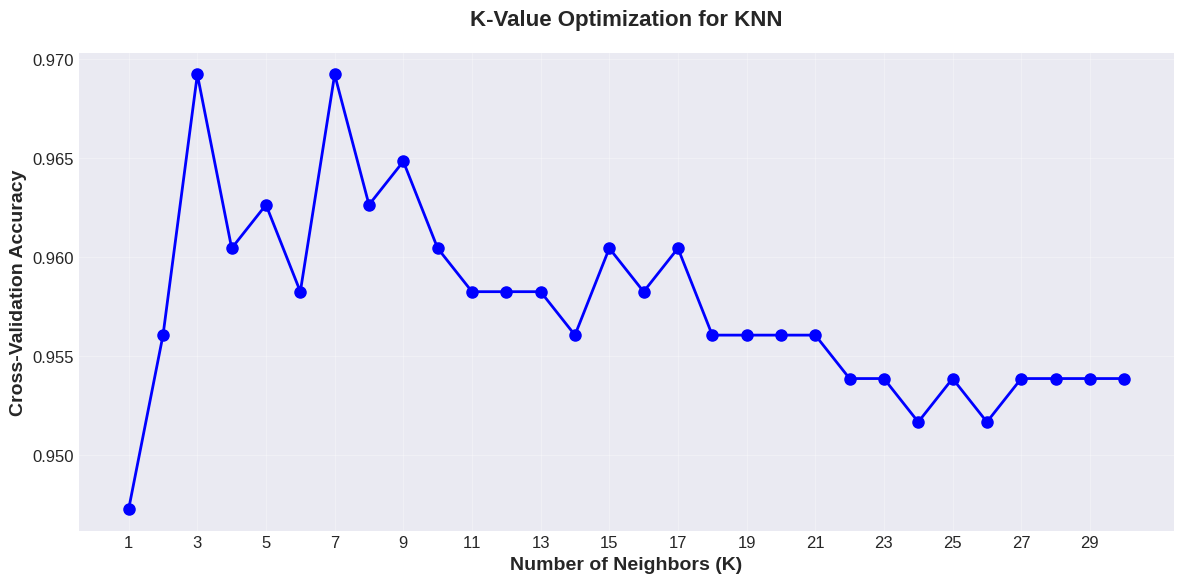

Optimal K value: 3
Best CV Accuracy: 0.9692

Test Set Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



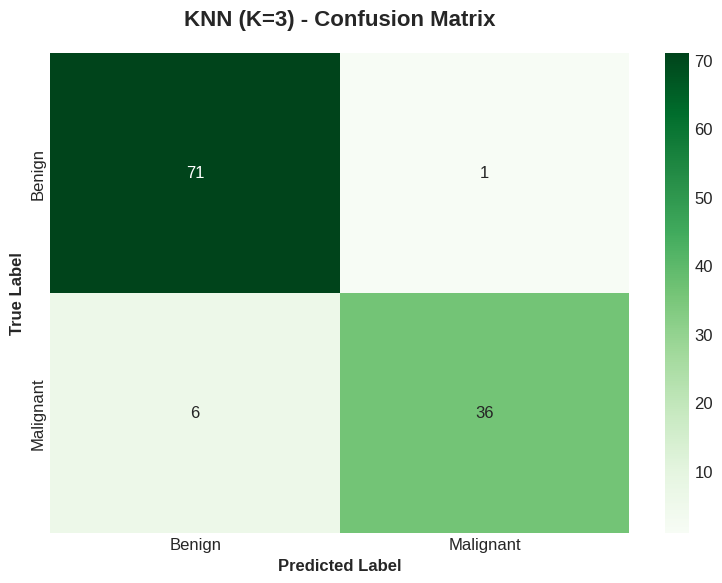

In [19]:
k_range = range(1, 31)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(12, 6))
plt.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)', fontsize=14, fontweight='bold')
plt.ylabel('Cross-Validation Accuracy', fontsize=14, fontweight='bold')
plt.title('K-Value Optimization for KNN', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(k_scores)]
print(f"Optimal K value: {optimal_k}")
print(f"Best CV Accuracy: {max(k_scores):.4f}")

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_pred_proba_knn = knn.predict_proba(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nTest Set Accuracy: {accuracy_knn:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Malignant']))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'KNN (K={optimal_k}) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


LINEAR Kernel - Accuracy: 0.9649

RBF Kernel - Accuracy: 0.9737

POLY Kernel - Accuracy: 0.8860
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



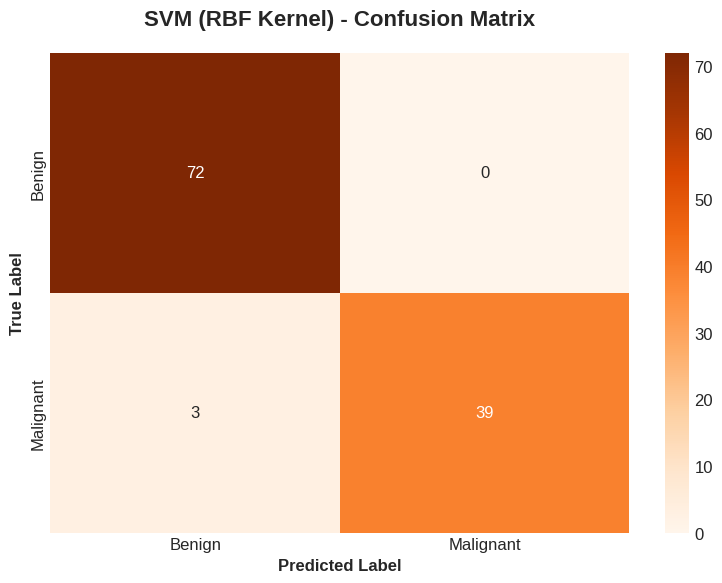


Number of Support Vectors: 82
Support Vectors per class: [42 40]


In [21]:
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    svm_results[kernel] = accuracy
    print(f"\n{kernel.upper()} Kernel - Accuracy: {accuracy:.4f}")

svm_rbf = SVC(kernel='rbf', probability=True, random_state=42, C=10, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)


y_pred_svm = svm_rbf.predict(X_test_scaled)
y_pred_proba_svm = svm_rbf.predict_proba(X_test_scaled)


accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Benign', 'Malignant']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('SVM (RBF Kernel) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nNumber of Support Vectors: {len(svm_rbf.support_)}")
print(f"Support Vectors per class: {svm_rbf.n_support_}")

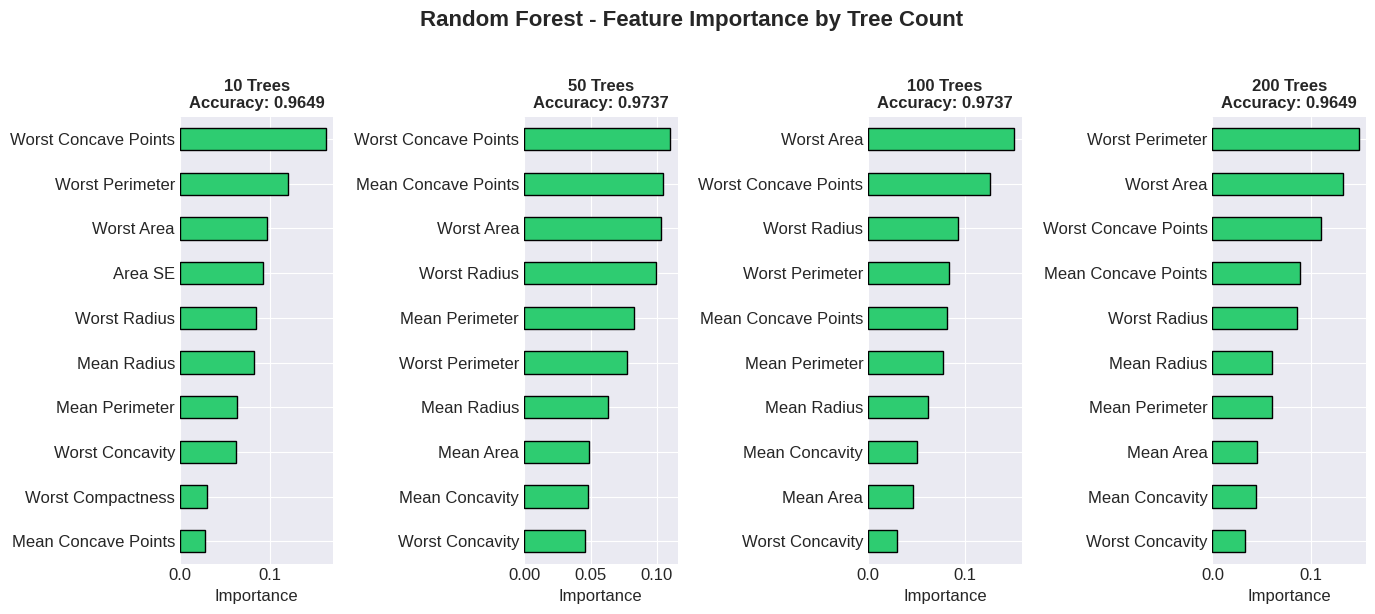

Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



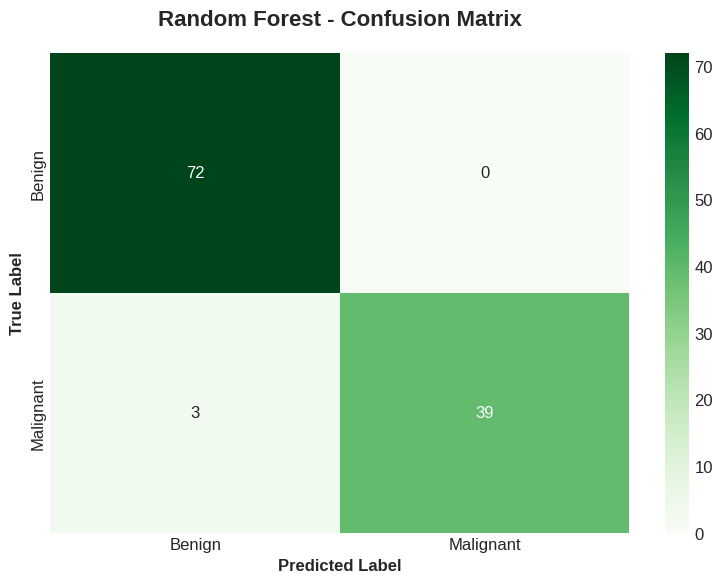

In [23]:
n_estimators_list = [10, 50, 100, 200]
rf_results = {}

plt.figure(figsize=(14, 6))

for i, n_est in enumerate(n_estimators_list, 1):
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    rf_results[n_est] = accuracy


    plt.subplot(1, 4, i)
    importance = pd.Series(rf.feature_importances_, index=feature_columns)
    top_features = importance.nlargest(10)
    top_features.plot(kind='barh', color='#2ecc71', edgecolor='black')
    plt.title(f'{n_est} Trees\nAccuracy: {accuracy:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()

plt.suptitle('Random Forest - Feature Importance by Tree Count', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


rf_final = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5,
                                  random_state=42, n_jobs=-1)
rf_final.fit(X_train_scaled, y_train)


y_pred_rf = rf_final.predict(X_test_scaled)
y_pred_proba_rf = rf_final.predict_proba(X_test_scaled)


accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))


cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Random Forest - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



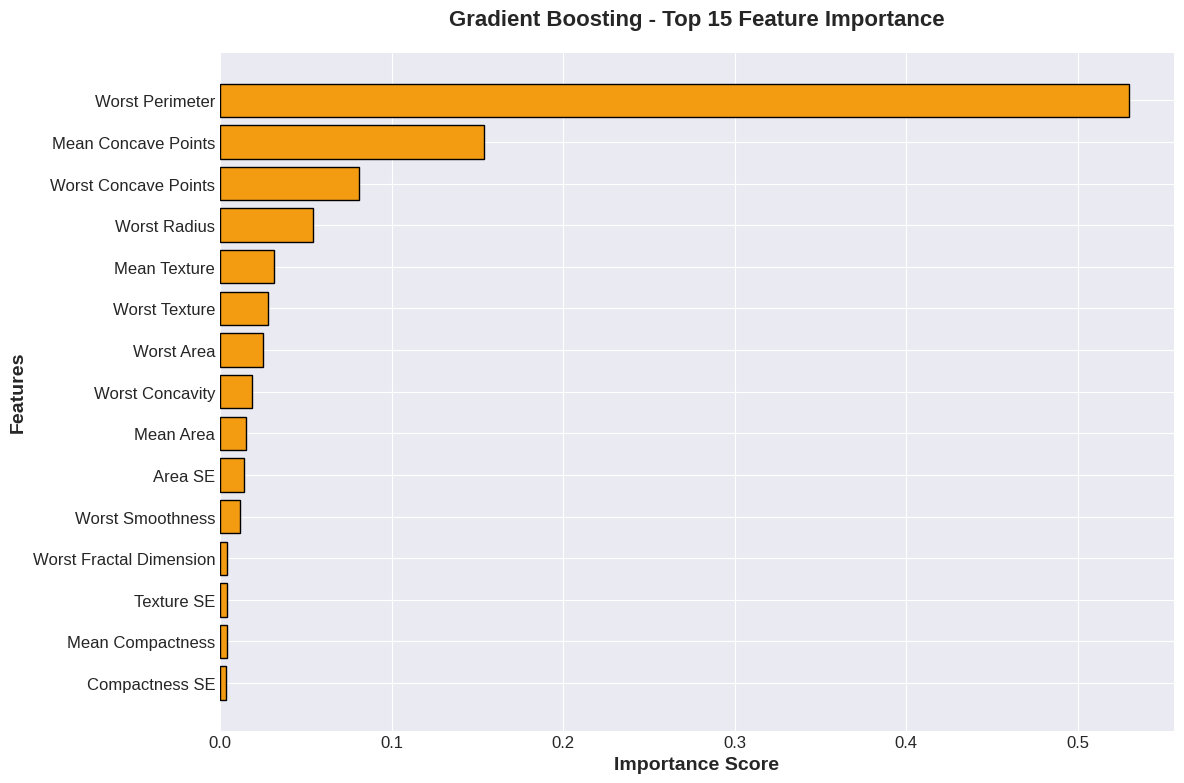

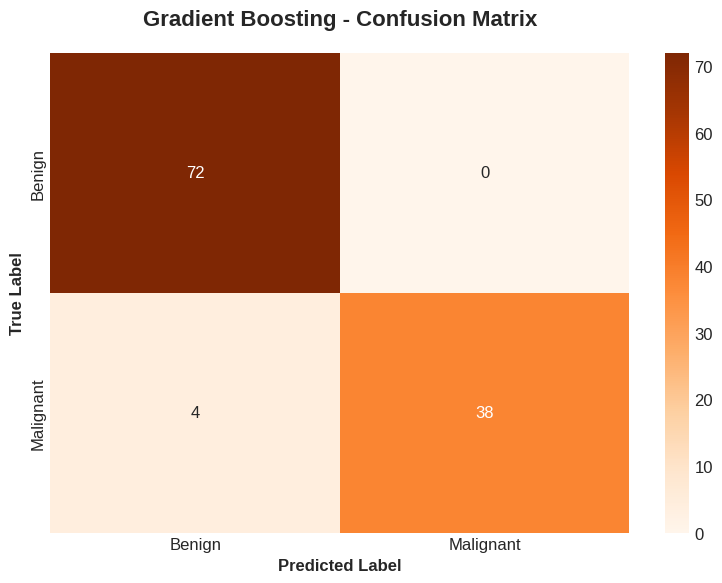

In [28]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)


y_pred_gb = gb.predict(X_test_scaled)
y_pred_proba_gb = gb.predict_proba(X_test_scaled)


accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['Benign', 'Malignant']))


feature_importance_gb = pd.DataFrame({
    'feature': feature_columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)


plt.figure(figsize=(12, 8))
top_features_gb = feature_importance_gb.head(15)
plt.barh(range(len(top_features_gb)), top_features_gb['importance'].values, color='#f39c12', edgecolor='black')
plt.yticks(range(len(top_features_gb)), top_features_gb['feature'].values)
plt.xlabel('Importance Score', fontsize=14, fontweight='bold')
plt.ylabel('Features', fontsize=14, fontweight='bold')
plt.title('Gradient Boosting - Top 15 Feature Importance', fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Gradient Boosting - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [25]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train_scaled, y_train)


y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Malignant']))


feature_importance_xgb = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(10).to_string(index=False))

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


Top 10 Most Important Features (XGBoost):
             feature  importance
     Worst Perimeter    0.325854
 Mean Concave Points    0.168878
        Worst Radius    0.132685
Worst Concave Points    0.107395
     Worst Concavity    0.034402
       Smoothness SE    0.024641
       Worst Texture    0.021746
           Mean Area    0.021613
        Mean Texture    0.020148
           Radius SE    0.015719


Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



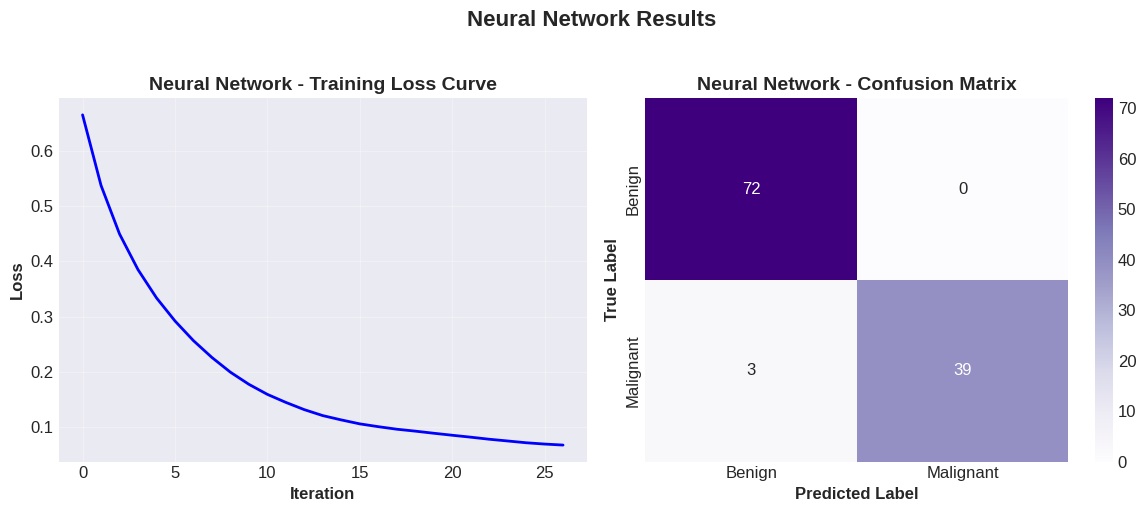

In [27]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                   max_iter=1000, random_state=42, early_stopping=True, validation_fraction=0.1)
nn.fit(X_train_scaled, y_train)


y_pred_nn = nn.predict(X_test_scaled)
y_pred_proba_nn = nn.predict_proba(X_test_scaled)


accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Accuracy: {accuracy_nn:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Benign', 'Malignant']))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(nn.loss_curve_, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Neural Network - Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Neural Network - Confusion Matrix', fontsize=14, fontweight='bold')

plt.suptitle('Neural Network Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Model Performance Comparison (Sorted by Accuracy):
              Model  Accuracy  Precision   Recall  F1-Score
          SVM (RBF)  0.973684   1.000000 0.928571  0.962963
     Neural Network  0.973684   1.000000 0.928571  0.962963
      Random Forest  0.973684   1.000000 0.928571  0.962963
  Gradient Boosting  0.964912   1.000000 0.904762  0.950000
Logistic Regression  0.964912   0.975000 0.928571  0.951220
            XGBoost  0.964912   1.000000 0.904762  0.950000
                KNN  0.938596   0.972973 0.857143  0.911392


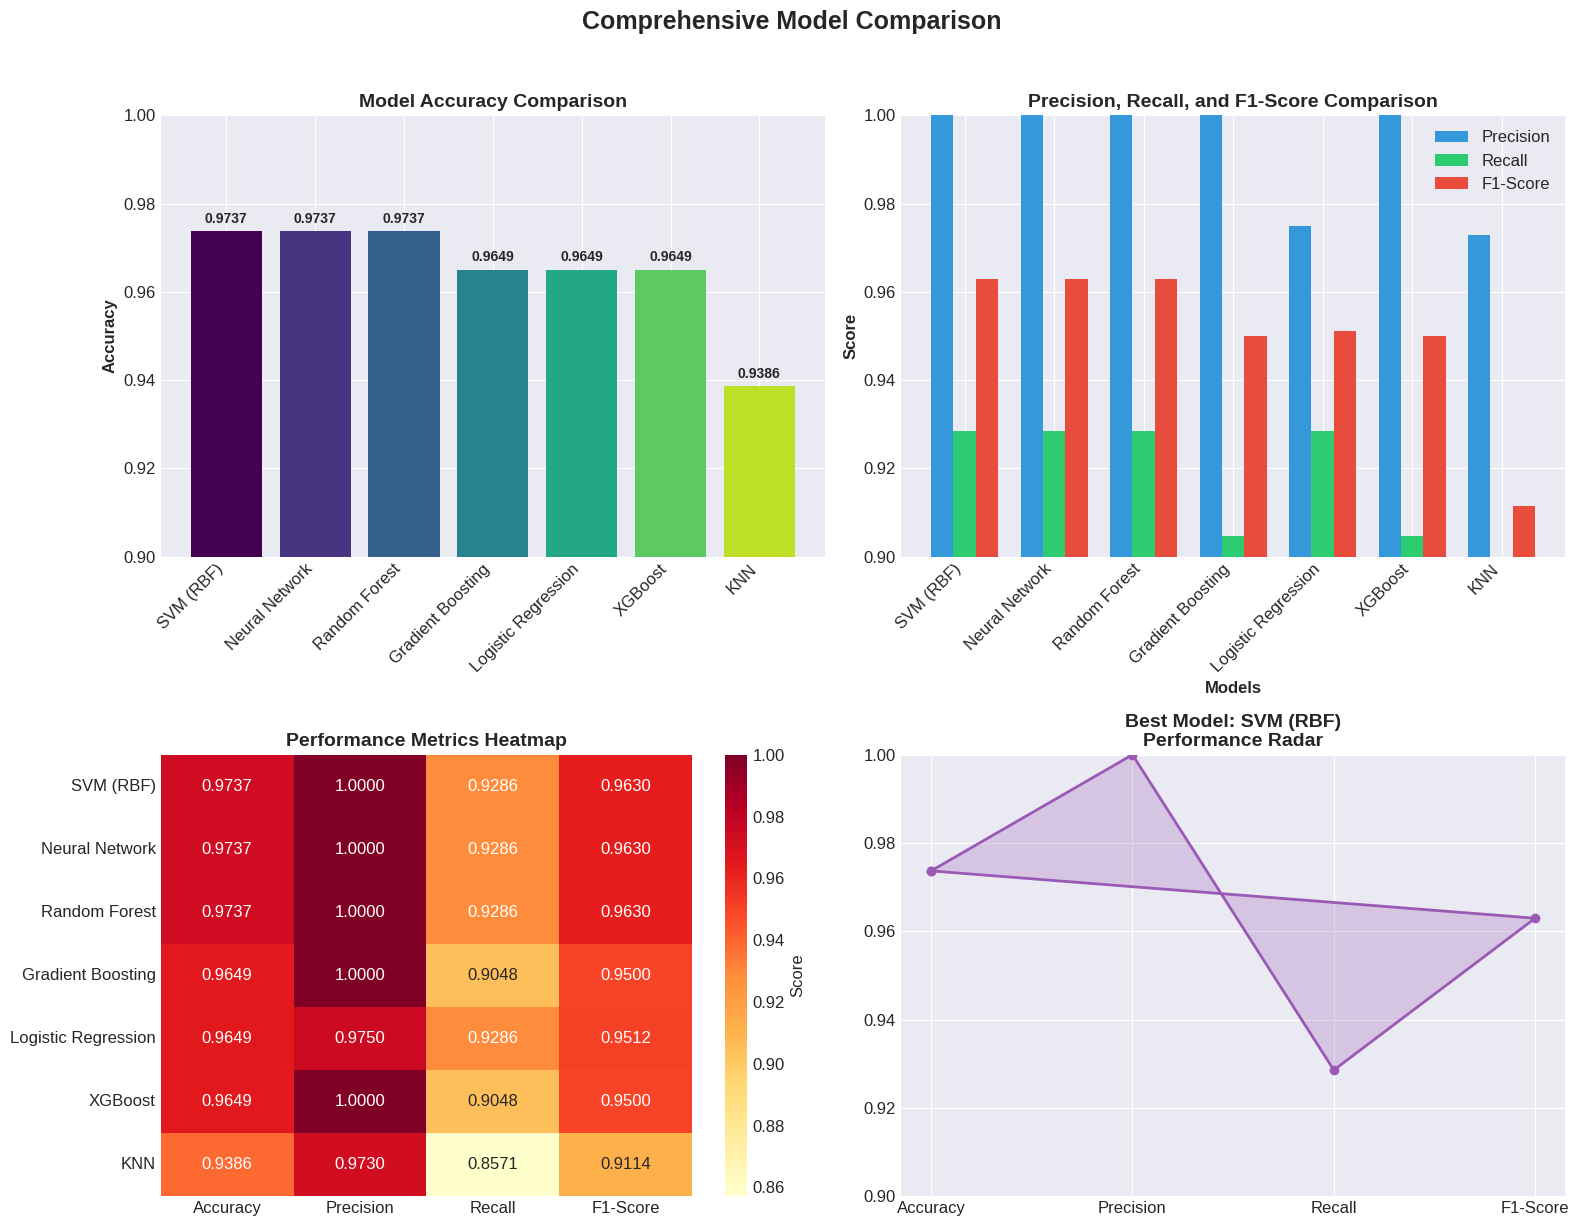

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = {
    'Logistic Regression': y_pred_log,
    'KNN': y_pred_knn,
    'SVM (RBF)': y_pred_svm,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

if 'y_pred_xgb' in locals() and y_pred_xgb is not None:
    models['XGBoost'] = y_pred_xgb

models['Neural Network'] = y_pred_nn


results = []
for model_name, y_pred in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })


comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("\nModel Performance Comparison (Sorted by Accuracy):")
print(comparison_df.to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(comparison_df)))
bars = ax1.bar(comparison_df['Model'], comparison_df['Accuracy'], color=colors)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.set_ylim([0.9, 1.0])
for bar, val in zip(bars, comparison_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')


ax2 = axes[0, 1]
x = np.arange(len(comparison_df))
width = 0.25
ax2.bar(x - width, comparison_df['Precision'], width, label='Precision', color='#3498db')
ax2.bar(x, comparison_df['Recall'], width, label='Recall', color='#2ecc71')
ax2.bar(x + width, comparison_df['F1-Score'], width, label='F1-Score', color='#e74c3c')
ax2.set_xlabel('Models', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.set_ylim([0.9, 1.0])


ax3 = axes[1, 0]
metrics_matrix = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].values
sns.heatmap(metrics_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            yticklabels=comparison_df['Model'], ax=ax3, cbar_kws={'label': 'Score'})
ax3.set_title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')


ax4 = axes[1, 1]
best_model = comparison_df.iloc[0]
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = best_model[1:5].values.tolist()
values += values[:1]

angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
angles += angles[:1]

ax4.plot(angles, values, 'o-', linewidth=2, color='#9b59b6')
ax4.fill(angles, values, alpha=0.25, color='#9b59b6')
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories)
ax4.set_ylim([0.9, 1.0])
ax4.set_title(f"Best Model: {best_model['Model']}\nPerformance Radar", fontsize=14, fontweight='bold')

plt.suptitle('Comprehensive Model Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

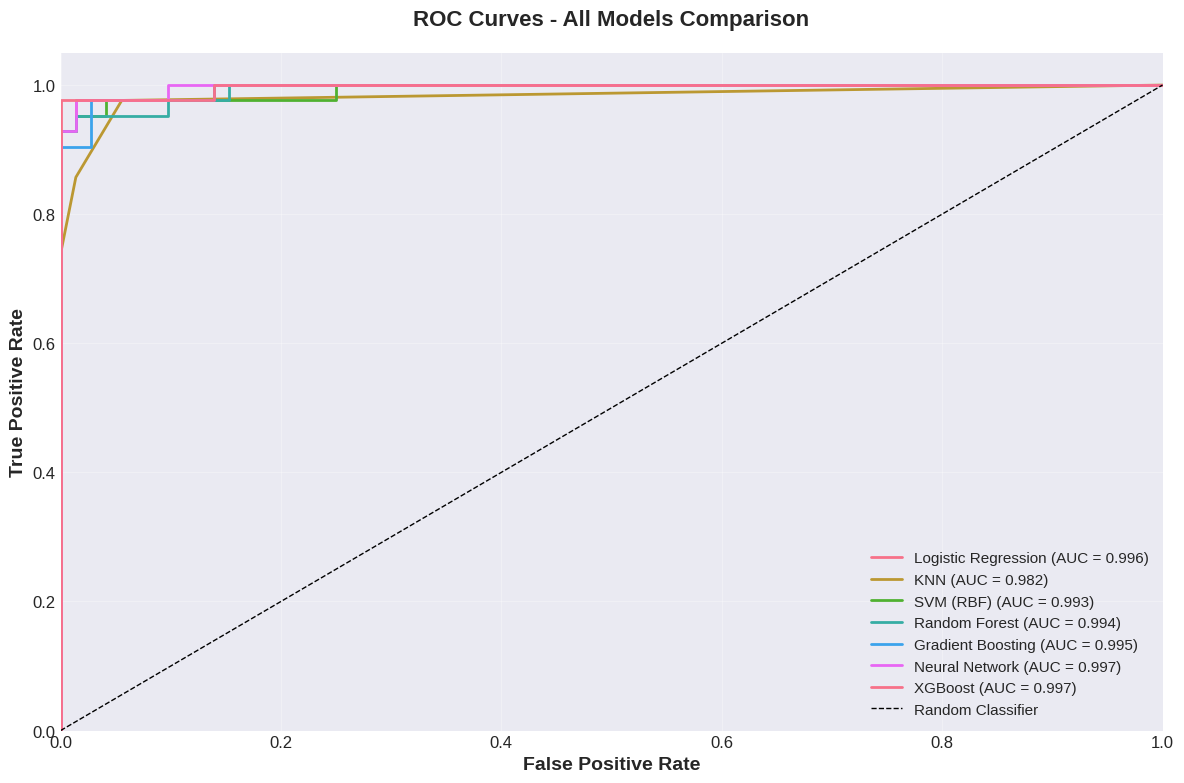


AUC Scores (Area Under ROC Curve):
              Model  AUC Score
     Neural Network   0.997024
            XGBoost   0.996693
Logistic Regression   0.996032
  Gradient Boosting   0.994709
      Random Forest   0.993717
          SVM (RBF)   0.992725
                KNN   0.982474


In [32]:
plt.figure(figsize=(12, 8))


prob_models = {
    'Logistic Regression': y_pred_proba_log[:, 1],
    'KNN': y_pred_proba_knn[:, 1],
    'SVM (RBF)': y_pred_proba_svm[:, 1],
    'Random Forest': y_pred_proba_rf[:, 1],
    'Gradient Boosting': y_pred_proba_gb[:, 1],
    'Neural Network': y_pred_proba_nn[:, 1]
}

if 'y_pred_proba_xgb' in locals() and y_pred_proba_xgb is not None:
    prob_models['XGBoost'] = y_pred_proba_xgb[:, 1]


for model_name, y_proba in prob_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curves - All Models Comparison', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


auc_scores = {}
for model_name, y_proba in prob_models.items():
    auc_scores[model_name] = auc(roc_curve(y_test, y_proba)[0], roc_curve(y_test, y_proba)[1])

auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'AUC Score'])
auc_df = auc_df.sort_values('AUC Score', ascending=False)
print("\nAUC Scores (Area Under ROC Curve):")
print(auc_df.to_string(index=False))

In [33]:
def predict_breast_cancer(new_patient_features, model=rf_final, scaler=scaler, feature_names=feature_columns):
    """
    Predict breast cancer diagnosis for a new patient

    Parameters:
    new_patient_features: array-like of 30 features in the correct order
    model: trained classifier
    scaler: fitted StandardScaler
    feature_names: list of feature names

    Returns:
    prediction and probability
    """

    new_patient = np.array(new_patient_features).reshape(1, -1)
    new_patient_scaled = scaler.transform(new_patient)
    prediction = model.predict(new_patient_scaled)[0]
    probability = model.predict_proba(new_patient_scaled)[0]


    result = "Malignant (Cancerous)" if prediction == 1 else "Benign (Non-Cancerous)"

    return result, probability


sample_patient = X_train.mean().values


result, prob = predict_breast_cancer(sample_patient)
print(f"\nSample Patient Features (mean values from training set):")
print(f"Number of features: {len(sample_patient)}")

print(f"\nPrediction Result: {result}")
print(f"Probability Distribution:")
print(f"  • Benign: {prob[0]:.4f} ({prob[0]*100:.2f}%)")
print(f"  • Malignant: {prob[1]:.4f} ({prob[1]*100:.2f}%)")

print(f"\nConfidence Level: {'High' if max(prob) > 0.8 else 'Medium' if max(prob) > 0.6 else 'Low'}")


def explain_prediction(features, model=rf_final, feature_names=feature_columns):
    """
    Explain which features contributed most to the prediction
    """
    mportance = model.feature_importances_
    explanation = pd.DataFrame({
        'Feature': feature_names,
        'Value': features,
        'Importance': importance
    })
    explanation = explanation.sort_values('Importance', ascending=False)

    return explanation.head(10)


print("\nTop 10 features that influenced this prediction:")
explanation = explain_prediction(sample_patient)
print(explanation.to_string(index=False))


Sample Patient Features (mean values from training set):
Number of features: 30

Prediction Result: Benign (Non-Cancerous)
Probability Distribution:
  • Benign: 0.6933 (69.33%)
  • Malignant: 0.3067 (30.67%)

Confidence Level: Medium

Top 10 features that influenced this prediction:
             Feature      Value  Importance
     Worst Perimeter 107.860484    0.147912
          Worst Area 890.569231    0.132269
Worst Concave Points   0.115491    0.110114
 Mean Concave Points   0.049015    0.088200
        Worst Radius  16.351514    0.085116
         Mean Radius  14.166077    0.060554
      Mean Perimeter  92.215868    0.060465
           Mean Area 659.578242    0.044701
      Mean Concavity   0.089184    0.044091
     Worst Concavity   0.275166    0.032828
